## Real-world vessel info from AIS data

In this notebook, we show how to retrieve and analyse information from AIS messages.

#### 1. Imports

In [ ]:
# package(s) used for creating and geo-locating the graph
import networkx as nx  
import shapely.geometry
from shapely import wkt
import pyproj

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime, time
import simpy
import opentnsim
from opentnsim import core

# package(s) needed for data handling and inspecting output
import numpy as np
import pathlib
import os
import pandas as pd
import geopandas as gpd
#import movingpandas # conda install movingpandas, conda install stonesoup

# package(s) needed for plotting
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib.ticker import MaxNLocator
import folium

print('This notebook is executed with OpenTNSim version {}'.format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.7


#### 2. Load and read the data

For this example we'll use a representative AIS data file called "ais.csv". Make sure to have this file in a known (and convenient) directory. We'll use the combination of pandas, geopandas and movingpandas to read the data.
Pandas reads the data as a table. Geopandas adds the location and movingpandas adds the time information. 
The result is that we can use data as table, feature (geospatial) and trajectory (moving objects). 

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [3]:
# Determine where your data file is and create the directory
data_dir = pathlib.Path('./data')

In [4]:
ais_df = pd.read_csv(data_dir / 'ais.csv')
ais_df['geometry'] = ais_df.apply(lambda x: shapely.geometry.Point(x['LON'], x['LAT']), axis=1)

#### 2.1 Stationary vessel positions (analyse ship properties)

In [5]:
# Ensure geometry is parsed correctly
if isinstance(ais_df['geometry'].iloc[0], str):
    ais_df['geometry'] = ais_df['geometry'].apply(wkt.loads)

# Create folium map centered on average coordinates
map_center = [ais_df['LAT'].mean() + 0.1, ais_df['LON'].mean() - 0.35]
m = folium.Map(location=map_center, zoom_start=10)

# Normalize speed for color mapping
norm = colors.Normalize(vmin=ais_df['SPEED'].min(), vmax=ais_df['SPEED'].max())
colormap = plt.get_cmap('viridis')

# Add points to the map with name and speed in popup
for _, row in ais_df.iterrows():
    if pd.notnull(row['geometry']) and pd.notnull(row['SPEED']):

        lat, lon = row['geometry'].y, row['geometry'].x
        speed = row['SPEED']
        name = row['name'] if pd.notnull(row['name']) else 'Unknown'
        rgba = colormap(norm(speed))
        hex_color = colors.to_hex(rgba)
        popup_text = f"Name: {name}<br>Speed: {speed}"
        folium.CircleMarker(
            location=[lat, lon],
            radius=5,
            color=hex_color,
            fill=True,
            fill_color=hex_color,
            fill_opacity=0.7,
            popup=folium.Popup(popup_text, max_width=200)
        ).add_to(m)

# Display the map
m


In [6]:
ais_df.head()

,Unnamed: 0,LAT,LON,SPEED,COURSE,HEADING,ELAPSED,DESTINATION,FLAG,LENGTH,ROT,SHIPNAME,SHIPTYPE,SHIP_ID,WIDTH,L_FORE,W_LEFT,DWT,GT_SHIPTYPE,TYPE_IMG,TYPE_NAME,STATUS_NAME,vessel_type,terminal_type,name,length,width,ID,draught_empty,draught_full,height_empty,height_full,v,installed_power,terminal,geometry
0,0,52.19487,3.585885,1.0,281.0,215.0,2.0,FOR ORDER,BS,228.0,2.0,ALFA BALTICA,8,994899,42.0,198.0,16.0,106373.0,17,NaN,NaN,NaN,Crude Oil Tanker,Liquid,ALFA BALTICA,228.0,42.0,994899,5,5,5,5,5.1,1000,Liquid,POINT (3.585885 52.19487)
1,1,52.06665,3.809318,116.0,304.0,312.0,1.0,EEMUU,MT,248.0,6.0,DAYTONA,8,149950,43.0,208.0,27.0,115896.0,17,NaN,NaN,NaN,Crude Oil Tanker,Liquid,DAYTONA,248.0,43.0,149950,5,5,5,5,5.1,1000,Liquid,POINT (3.809318 52.06665)
2,2,52.05602,3.585517,121.0,267.0,269.0,1.0,DAMIETTA,MH,189.0,0.0,ST PAUL,7,201740,32.0,170.0,20.0,57982.0,6,NaN,NaN,NaN,Bulk Carrier,Bulk,ST PAUL,189.0,32.0,201740,5,5,5,5,5.1,1000,Bulk,POINT (3.585517 52.05602)
3,3,52.17560,3.562725,0.0,254.0,174.0,3.0,RUMMK >> NLRTM,LR,249.0,-1.0,GEORGY MASLOV,8,755598,46.0,202.0,25.0,122018.0,17,NaN,NaN,NaN,Crude Oil Tanker,Liquid,GEORGY MASLOV,249.0,46.0,755598,5,5,5,5,5.1,1000,Liquid,POINT (3.562725 52.1756)
4,4,52.20705,3.682493,1.0,113.0,183.0,6.0,OFF RTM,BS,274.0,2.0,SYDNEY SPIRIT,8,713693,48.0,228.0,22.0,158542.0,17,NaN,NaN,NaN,Crude Oil Tanker,Liquid,SYDNEY SPIRIT,274.0,48.0,713693,5,5,5,5,5.1,1000,Liquid,POINT (3.682493 52.20705)


#### 3. Create a list of vessels

Instead of creating a vessel class, it is also possible to create a list of vessels from AIS-data. The data from the 'ais.csv'-file can be filtered by multiple different criteria. For this example we will filter by a certain terminal type.

In [7]:
# Select vessels that go to certain ports. In this case, the vessels that go to the 'Other' terminals are removed from the list.
vessels = ais_df.query('terminal != "Other"')
vessels[['name', 'geometry', 'vessel_type', 'terminal', 'length']]

,name,geometry,vessel_type,terminal,length
0,ALFA BALTICA,POINT (3.585885 52.19487),Crude Oil Tanker,Liquid,228.0
1,DAYTONA,POINT (3.809318 52.06665),Crude Oil Tanker,Liquid,248.0
2,ST PAUL,POINT (3.585517 52.05602),Bulk Carrier,Bulk,189.0
3,GEORGY MASLOV,POINT (3.562725 52.1756),Crude Oil Tanker,Liquid,249.0
4,SYDNEY SPIRIT,POINT (3.682493 52.20705),Crude Oil Tanker,Liquid,274.0
5,LOTUS A,POINT (3.621987 52.19629),Container,Container1,335.0
6,ASTER ALVAR,POINT (3.686642 52.13476),Oil/Chemical Tanker,Liquid,129.0
7,NAVIG8 ANDESINE,POINT (3.710833 52.19441),Oil/Chemical Tanker,Liquid,184.0
8,SEAVOYAGER,POINT (3.593533 52.17705),Crude Oil Tanker,Liquid,274.0
9,CORAL LACERA,POINT (3.703472 52.12477),LPG Tanker,Liquid,108.0


#### Specific data retrieval

This list of vessels can than be further manipulated to retrieve more specific information. For exmaple, if we want to know the length distribution of vessels arriving at 'Liquid' terminal types, the following visualisation can be done.

,name,geometry,vessel_type,terminal,length,width,DWT
4,SYDNEY SPIRIT,POINT (3.682493 52.20705),Crude Oil Tanker,Liquid,274.0,48.0,158542.0
8,SEAVOYAGER,POINT (3.593533 52.17705),Crude Oil Tanker,Liquid,274.0,48.0,159233.0
3,GEORGY MASLOV,POINT (3.562725 52.1756),Crude Oil Tanker,Liquid,249.0,46.0,122018.0
1,DAYTONA,POINT (3.809318 52.06665),Crude Oil Tanker,Liquid,248.0,43.0,115896.0
0,ALFA BALTICA,POINT (3.585885 52.19487),Crude Oil Tanker,Liquid,228.0,42.0,106373.0
7,NAVIG8 ANDESINE,POINT (3.710833 52.19441),Oil/Chemical Tanker,Liquid,184.0,27.0,37596.0
13,BOCHEM ANTWERP,POINT (3.577317 52.16278),Oil/Chemical Tanker,Liquid,141.0,24.0,19806.0
6,ASTER ALVAR,POINT (3.686642 52.13476),Oil/Chemical Tanker,Liquid,129.0,19.0,11596.0
9,CORAL LACERA,POINT (3.703472 52.12477),LPG Tanker,Liquid,108.0,16.0,4999.0
11,KEY WEST,POINT (3.7321 52.15103),Oil/Chemical Tanker,Liquid,90.0,14.0,3741.0


For terminal type Liquid, maximum ship length = 274.0, minimum = 90.0, mean = 192.5
For terminal type Liquid, maximum ship width = 48.0, minimum = 14.0, mean = 32.7
Average DWT for liquid terminal = 73980.0 tonnes


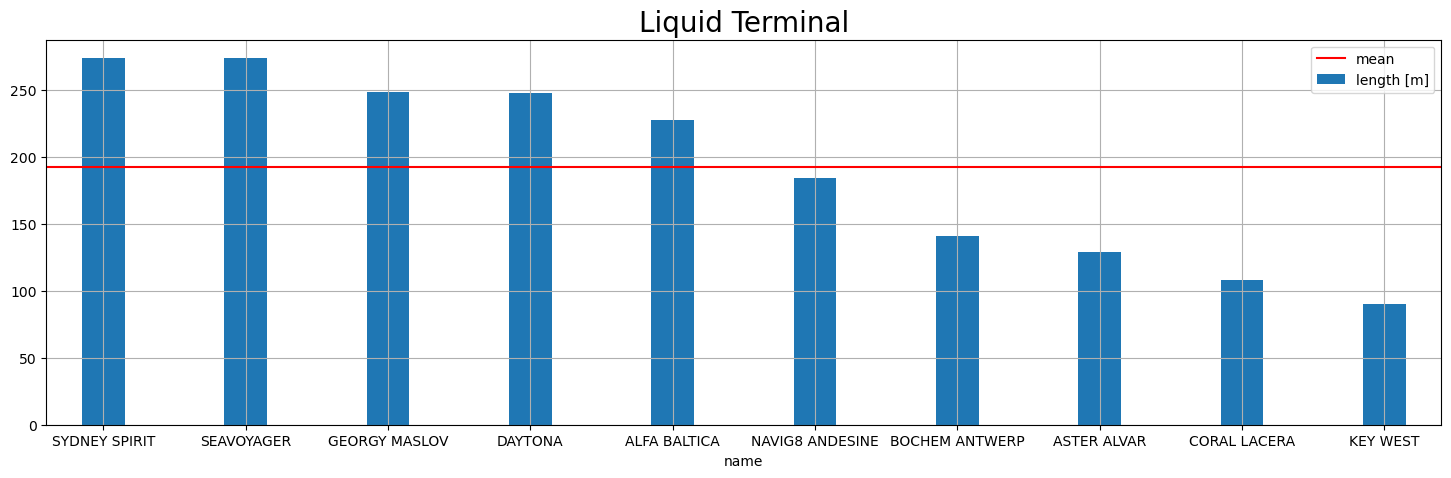

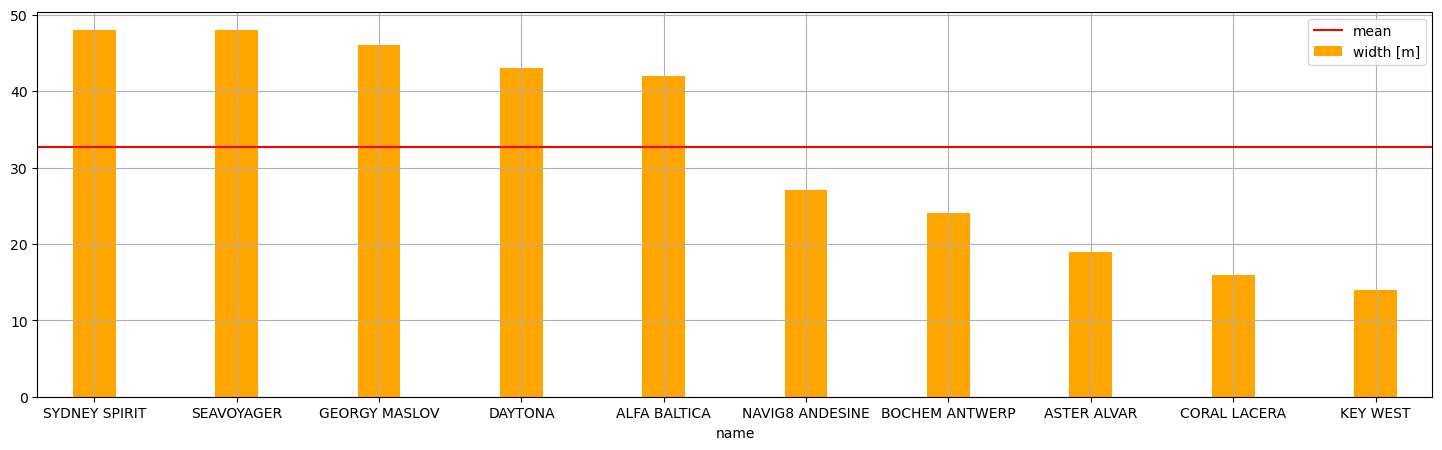

In [8]:
is_liquid = vessels['terminal']=='Liquid'
df_liquid = vessels[is_liquid]

df_liquid = df_liquid.sort_values(by='length',ascending=False)

display(df_liquid[['name', 'geometry', 'vessel_type', 'terminal', 'length', 'width', 'DWT']])

plot = df_liquid.plot.bar(x='name', y='length', rot=0, figsize=(18,5), width = 0.3, grid=(True));
plot.axhline(y=df_liquid['length'].mean(),color= 'r', label = 'mean')
plot.legend(['mean', 'length [m]'])
plt.title('Liquid Terminal', fontsize = 20)

plot2 = df_liquid.plot.bar(x= 'name',y = 'width', rot=0, figsize=(18,5), width = 0.3,grid=(True), color='orange');
plot2.axhline(y=df_liquid['width'].mean(),color= 'r', label = 'mean')
plot2.legend(['mean', 'width [m]'])

max_length_liquid = df_liquid['length'].max()
min_length_liquid = df_liquid['length'].min()
mean_length_liquid = df_liquid['length'].mean()

max_width_liquid = df_liquid['width'].max()
min_width_liquid = df_liquid['width'].min()
mean_width_liquid = df_liquid['width'].mean()

# determine average DWT for q3.2
avg_DWT_liquid = df_liquid['DWT'].mean()

print(f'For terminal type Liquid, maximum ship length = {max_length_liquid:.1f}, minimum = {min_length_liquid:.1f}, mean = {mean_length_liquid:.1f}')
print(f'For terminal type Liquid, maximum ship width = {max_width_liquid:.1f}, minimum = {min_width_liquid:.1f}, mean = {mean_width_liquid:.1f}')
print(f'Average DWT for liquid terminal = {avg_DWT_liquid:.1f} tonnes')


#### 2.2 AIS data of a few vessels (analyse ship trajectories)

In [9]:
ais_df = pd.read_csv(data_dir / 'OD_1day.csv')
# ais_df['geometry'] = ais_df.apply(lambda x: shapely.geometry.Point(x['LON'], x['LAT']), axis=1)

In [10]:
ais_df

,shipname,latitude,longitude,geometry,length,width,draughtInland,RWS classification,P_installed,L_w,P_stat,latitude_D,longitude_D,geometry_D,average_speed,Maassluis,Nieuwe maas,Oude maas,Scheldt-Rhine,Zuid-Beveland,time_diff
0,testschip-1002,51.885433,4.455268,POINT (4.455267906188965 51.88543319702148),52.5,6.0,2.300,M2,300,1,16,51.881310,4.443803,POINT (4.443802833557129 51.88130950927734),2.039867,0,0,0,0,0,18827
1,testschip-1002-1,51.881367,4.444135,POINT (4.444135189056396 51.88136672973633),52.5,6.0,2.300,M2,300,1,16,51.884434,4.446205,POINT (4.446205139160156 51.88443374633789),2.014527,0,0,0,0,0,39589
2,testschip-1002-2,51.885376,4.455358,POINT (4.455358028411865 51.8853759765625),52.5,6.0,2.300,M2,300,1,16,51.901783,4.382028,POINT (4.382028102874756 51.90178298950195),2.707797,0,0,0,0,0,45802
3,testschip-1002-1-2,51.901802,4.382178,POINT (4.382177829742432 51.90180206298828),52.5,6.0,2.300,M2,300,1,16,51.885536,4.455478,POINT (4.455478191375732 51.88553619384766),2.001294,0,0,0,0,0,51803
4,testschip-1008,51.884151,4.421427,POINT (4.421426773071289 51.88415145874023),110.0,14.0,3.300,M10,2400,3,81,51.888901,4.362452,POINT (4.362452030181885 51.88890075683594),2.941795,0,0,0,0,0,27371
5,testschip-1008-1,51.887836,4.356310,POINT (4.35630989074707 51.88783645629883),110.0,14.0,3.300,M10,2400,3,81,51.445541,4.230388,POINT (4.230388164520264 51.44554138183594),4.144279,0,0,1,1,0,60122
6,testschip-1020,51.362358,4.288490,POINT (4.288489818572998 51.36235809326172),82.5,8.0,2.400,M5,640,2,33,51.729374,4.692785,POINT (4.692784786224365 51.72937393188477),4.563567,0,0,0,1,0,852
7,testschip-1027,51.327557,4.307925,POINT (4.307925224304199 51.32755661010742),80.0,11.0,2.200,C1b,175,1,9,51.345814,4.289143,POINT (4.289143085479736 51.3458137512207),1.716417,0,0,0,0,0,46566
8,testschip-1027-1,51.345875,4.289112,POINT (4.289112091064453 51.34587478637695),80.0,11.0,2.200,C1b,175,1,9,51.354206,3.794228,POINT (3.794228076934814 51.35420608520508),3.843239,0,0,0,0,0,52344
9,testschip-1031,51.704300,4.622723,POINT (4.62272310256958 51.70429992675781),80.0,9.0,2.575,M6,1070,2,39,51.897629,4.478528,POINT (4.478528022766113 51.89762878417969),3.642188,0,1,0,0,0,34505


In [11]:
ais_df[ais_df.shipname=='testschip-1002']

,shipname,latitude,longitude,geometry,length,width,draughtInland,RWS classification,P_installed,L_w,P_stat,latitude_D,longitude_D,geometry_D,average_speed,Maassluis,Nieuwe maas,Oude maas,Scheldt-Rhine,Zuid-Beveland,time_diff
0,testschip-1002,51.885433,4.455268,POINT (4.455267906188965 51.88543319702148),52.5,6.0,2.3,M2,300,1,16,51.88131,4.443803,POINT (4.443802833557129 51.88130950927734),2.039867,0,0,0,0,0,18827
